In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim


In [2]:
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets
from torchvision.transforms import v2, transforms

In [3]:
print(f'Cuda available: {torch.cuda.is_available()}')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using Device: {device}')

if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Cuda available: True
Using Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [4]:
from model import SimpleModel

In [5]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 32

trainset = datasets.MNIST(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = datasets.MNIST(root='./data', train=False,
                                       download=True, transform=transform)
testloader = DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('0', '1', '2', '3', '4', '5', '6', '7', '8', '9')

#classes = ('plane', 'car', 'bird', 'cat',
#           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


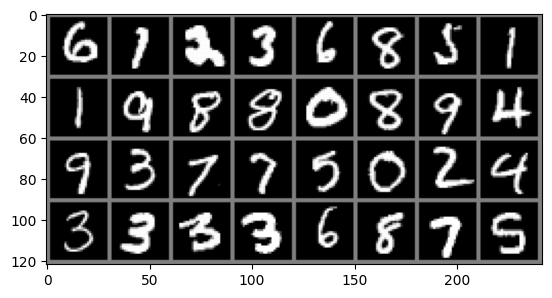

6     1     2     3     6     8     5     1     1     9     8     8     0     8     9     4     9     3     7     7     5     0     2     4     3     3     3     3     6     8     7     5    


(torch.Size([32, 3, 28, 28]),
 tensor([[[[-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           ...,
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.]],
 
          [[-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           ...,
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.]],
 
          [[-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           ...,
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.]]],
 
 
         [[[-1., -1., -1.,  

In [6]:

import matplotlib.pyplot as plt

def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

dataiter = iter(trainloader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images))
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

images.shape, images

In [7]:
model = SimpleModel(device).to(device)
load = True

if load:
    PATH = './files/number_model.pt'
    model = SimpleModel.load(PATH, device)

In [8]:
model.fit(trainloader, testloader)

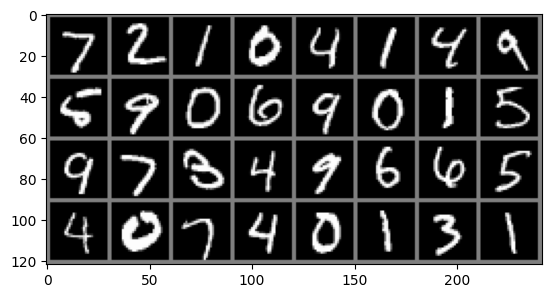

7     2     1     0     4     1     4     9     5     9     0     6     9     0     1     5     9     7     3     4     9     6     6     5     4     0     7     4     0     1     3     1    


In [9]:
dataiter = iter(testloader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images))
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [10]:
pred = model(images.to(device))

_, pred = torch.max(pred, 1)

pred

tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4, 9, 6, 6, 5,
        4, 0, 7, 4, 0, 1, 3, 1], device='cuda:0')

In [11]:
preds, y = model.predict(testloader)

In [12]:
preds

tensor([7, 2, 1,  ..., 4, 5, 6], device='cuda:0')

In [13]:
SimpleModel.compute_accuracy(preds, y)

0.9888

In [14]:
PATH = './files/number_model.pt'
model.save(PATH)